# Notebook 2: Statistical Tests

Tests run before modeling:
- ADF + KPSS (stationarity)
- Hurst Exponent (long memory)
- Kruskal-Wallis (seasonality)
- Tsay's Test (linearity vs nonlinearity)
- Granger Causality (feature selection)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = {'EPU': '#2563EB', 'CPU': '#16A34A', 'GPR': '#DC2626'}
print('Ready.')

Ready.


In [24]:
# Load all pre-computed results
stat_results   = pd.read_excel('../data/processed/stationarity_test_results.xlsx')
hurst_results  = pd.read_excel('../data/processed/hurst_exponent_results.xlsx')
season_results = pd.read_excel('../data/processed/seasonality_test_results.xlsx')
tsay_results   = pd.read_excel('../data/processed/tsays_test_results.xlsx')
granger_results= pd.read_excel('../data/processed/granger_causality_results.xlsx')
print('All result files loaded.')

All result files loaded.


## 1. Stationarity — ADF + KPSS

In [25]:
targets = stat_results[stat_results['Time Series'].isin(['EPU', 'CPU', 'GPR'])]
print(targets.to_string(index=False))

Time Series  KPSS P-Value    KPSS Result  ADF P-Value     ADF Result
        EPU          0.01 Non-Stationary     0.038301     Stationary
        CPU          0.01 Non-Stationary     0.921484 Non-Stationary
        GPR          0.10     Stationary     0.000002     Stationary


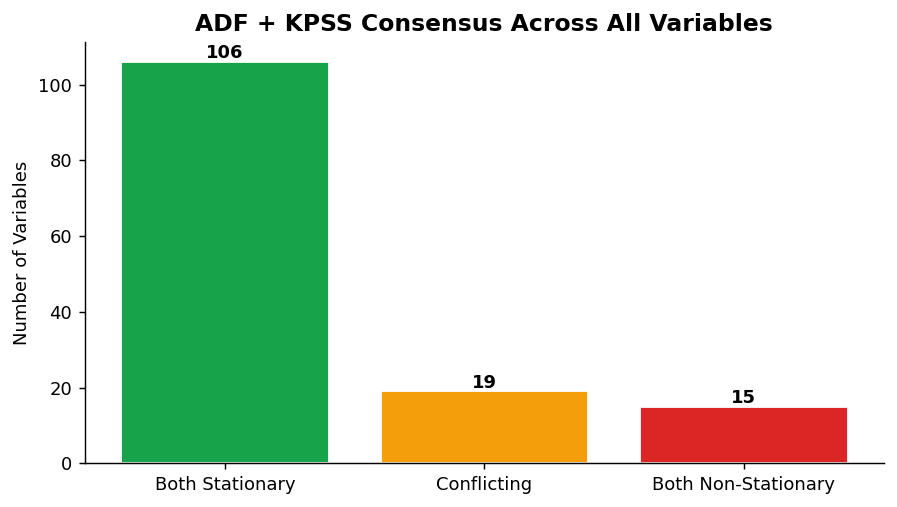

In [26]:
# Stationarity consensus bar chart
stat_results['ADF_binary']  = (stat_results['ADF Result'] == 'Stationary').astype(int)
stat_results['KPSS_binary'] = (stat_results['KPSS Result'] == 'Stationary').astype(int)

def consensus(row):
    if row['ADF_binary'] == 1 and row['KPSS_binary'] == 1:
        return 'Both Stationary'
    elif row['ADF_binary'] == 0 and row['KPSS_binary'] == 0:
        return 'Both Non-Stationary'
    else:
        return 'Conflicting'

stat_results['Consensus'] = stat_results.apply(consensus, axis=1)
counts = stat_results['Consensus'].value_counts()
palette = {'Both Stationary': '#16A34A', 'Both Non-Stationary': '#DC2626', 'Conflicting': '#F59E0B'}

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=[palette[k] for k in counts.index], edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontweight='bold')
ax.set_title('ADF + KPSS Consensus Across All Variables', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Variables')
plt.tight_layout()
plt.savefig('../outputs/01_stationarity_consensus.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Hurst Exponent

In [27]:
target_hurst = hurst_results[hurst_results['Variable'].isin(['EPU', 'CPU', 'GPR'])]
for _, row in target_hurst.iterrows():
    h = row['Hurst Exponent']
    memory = 'Strong persistence' if h > 0.7 else 'Moderate persistence' if h > 0.5 else 'Anti-persistent'
    print(f"{row['Variable']:5s}  H={h:.4f}  ->  {memory}")

EPU    H=0.7781  ->  Strong persistence
CPU    H=0.8040  ->  Strong persistence
GPR    H=0.6871  ->  Moderate persistence


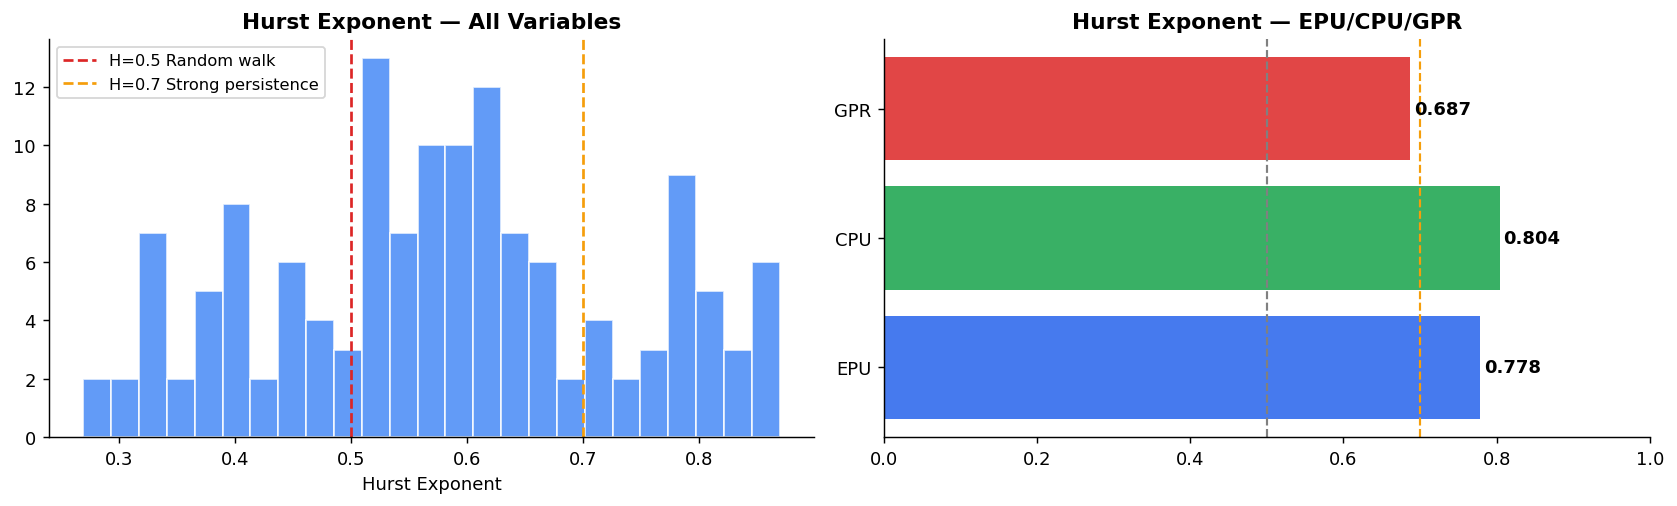

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

h_vals = hurst_results['Hurst Exponent']
ax1.hist(h_vals, bins=25, color='#3B82F6', alpha=0.8, edgecolor='white')
ax1.axvline(0.5, color='#DC2626', linestyle='--', linewidth=1.5, label='H=0.5 Random walk')
ax1.axvline(0.7, color='#F59E0B', linestyle='--', linewidth=1.5, label='H=0.7 Strong persistence')
ax1.set_title('Hurst Exponent — All Variables', fontweight='bold')
ax1.set_xlabel('Hurst Exponent')
ax1.legend(fontsize=9)

bars = ax2.barh(target_hurst['Variable'], target_hurst['Hurst Exponent'],
                color=[COLORS[v] for v in target_hurst['Variable']], alpha=0.85)
ax2.axvline(0.5, color='gray', linestyle='--', linewidth=1.2)
ax2.axvline(0.7, color='#F59E0B', linestyle='--', linewidth=1.2)
for bar, val in zip(bars, target_hurst['Hurst Exponent']):
    ax2.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold')
ax2.set_xlim(0, 1)
ax2.set_title('Hurst Exponent — EPU/CPU/GPR', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/02_hurst_exponent.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Seasonality Test

In [29]:
print(season_results[season_results['Time Series'].isin(['EPU','CPU','GPR'])].to_string(index=False))

Time Series      P-Value       Result
        EPU 1.101769e-12 Not Seasonal
        CPU 2.319630e-16 Not Seasonal
        GPR 3.406408e-13 Not Seasonal


## 4. Tsay's Test — Linearity

In [30]:
print(tsay_results[tsay_results['Time Series'].isin(['EPU','CPU','GPR'])].to_string(index=False))
print('\nCPU is Nonlinear -> motivates LightGBM in the hybrid model.')

Time Series  P-Value    Result
        EPU 0.351245    Linear
        CPU 0.001425 Nonlinear
        GPR 0.478969    Linear

CPU is Nonlinear -> motivates LightGBM in the hybrid model.


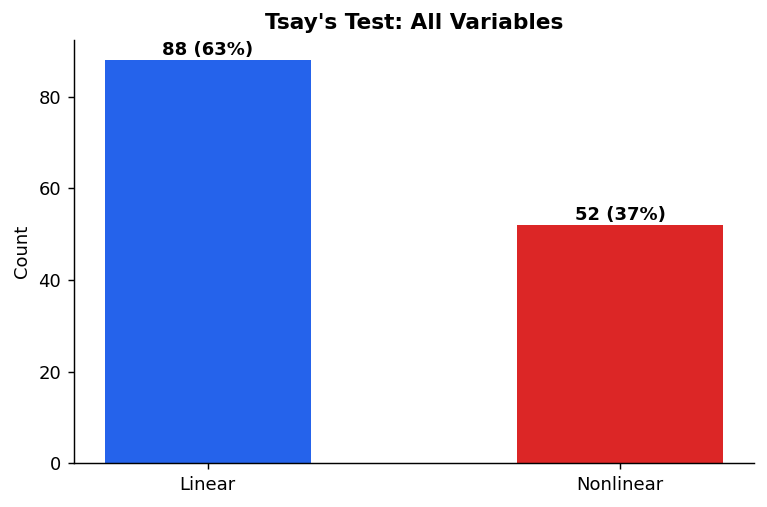

In [31]:
tsay_counts = tsay_results['Result'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
colors_tsay = {'Linear': '#2563EB', 'Nonlinear': '#DC2626'}
bars = ax.bar(tsay_counts.index, tsay_counts.values,
              color=[colors_tsay.get(k,'gray') for k in tsay_counts.index], width=0.5)
for bar, val in zip(bars, tsay_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val} ({val/len(tsay_results)*100:.0f}%)', ha='center', fontweight='bold')
ax.set_title("Tsay's Test: All Variables", fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/03_tsay_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Granger Causality

In [32]:
for target in ['EPU', 'CPU', 'GPR']:
    sub = granger_results[granger_results['Target Variable'] == target]
    sig = sub[sub['Result'] == 'Significant']
    print(f"{target}: {len(sig)} significant predictors")
    print(f"  Top 5: {sig.nsmallest(5,'Min P-Value')['Feature'].tolist()}\n")

EPU: 73 significant predictors
  Top 5: ['DPCERA3M086SBEA', 'CMRMTSPLx', 'RETAILx', 'INDPRO', 'IPFPNSS']

CPU: 59 significant predictors
  Top 5: ['RPI', 'CONSPI', 'CUSR0000SAD', 'credgdp', 'capr']

GPR: 4 significant predictors
  Top 5: ['mortg', 'DSERRG3M086SBEA', 'WPSFD49207', 'DDURRG3M086SBEA']



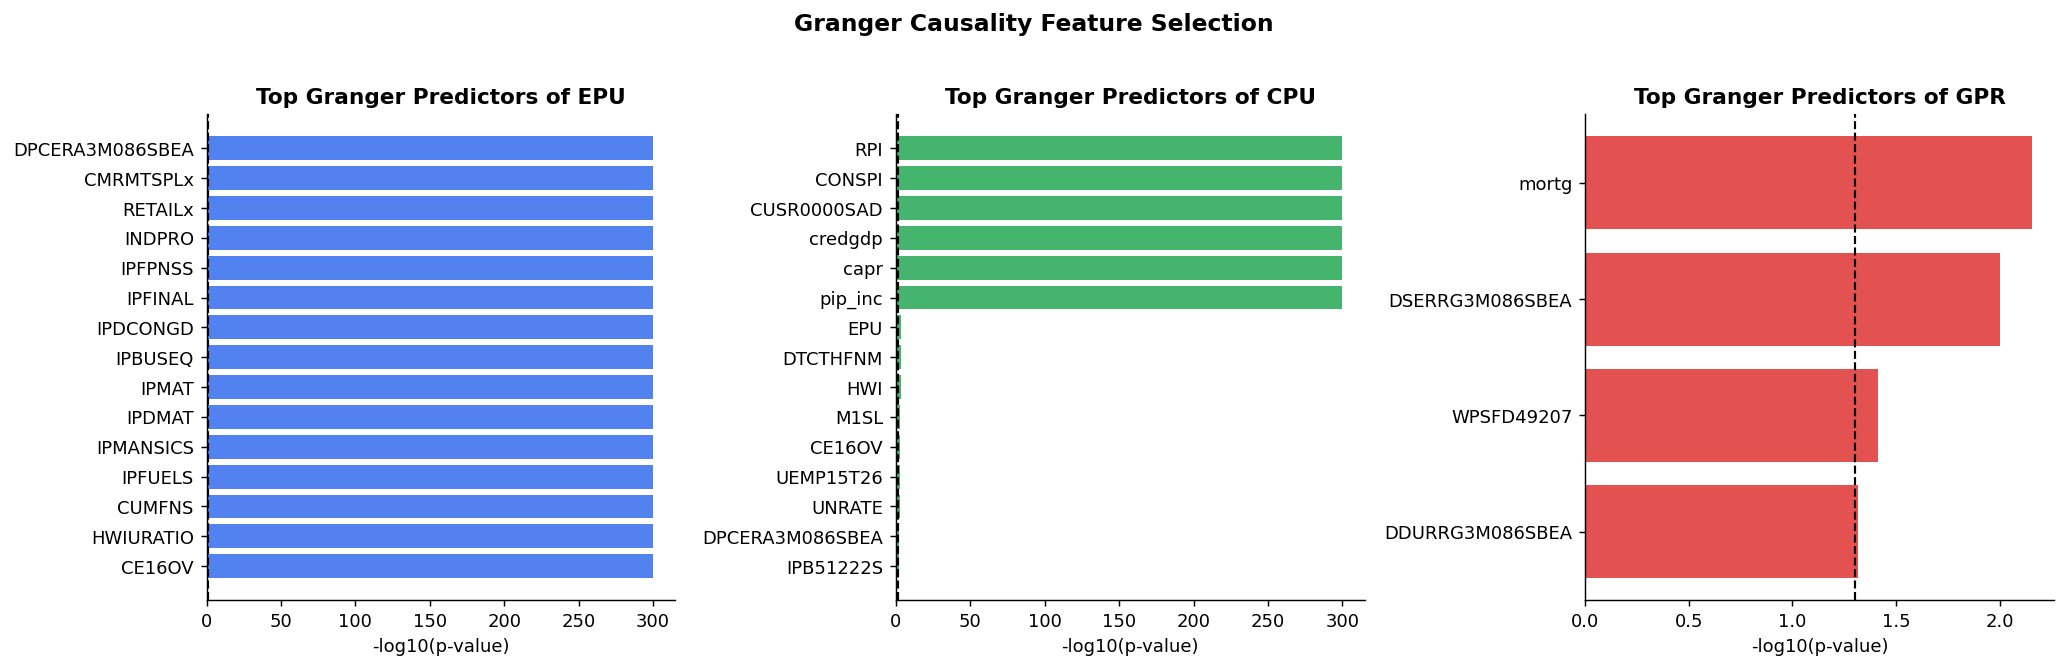

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, target in zip(axes, ['EPU', 'CPU', 'GPR']):
    sub = granger_results[
        (granger_results['Target Variable'] == target) &
        (granger_results['Result'] == 'Significant')
    ].nsmallest(15, 'Min P-Value').copy()
    sub['neg_log_p'] = -np.log10(sub['Min P-Value'].replace(0, 1e-300))
    ax.barh(sub['Feature'][::-1], sub['neg_log_p'][::-1], color=COLORS[target], alpha=0.8)
    ax.axvline(x=-np.log10(0.05), color='black', linestyle='--', linewidth=1.2)
    ax.set_title(f'Top Granger Predictors of {target}', fontweight='bold')
    ax.set_xlabel('-log10(p-value)')
plt.suptitle('Granger Causality Feature Selection', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/04_granger_causality.png', dpi=150, bbox_inches='tight')
plt.show()